In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy.stats import ttest_ind

# Load dataset
df_heart= pd.read_csv(r"C:\\Users\\Ajitha.Rajkumar\\OneDrive - Reliance Corporate IT Park Limited\\Desktop\\Python\\BA End term\\heart_disease_uci.csv")  # Replace with your path
df_heart.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [7]:
print(df_heart.info())
print(df_heart.describe())
print(df_heart.isnull().sum())
print("Shape:", df_heart.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  

In [8]:
# Analyze the breadth and depth of the dataset.
num_rows = df_heart.shape[0]
num_cols = df_heart.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

# Use the .info() method to understand the data types and missing values.
df_heart.info()

# Utilize the .memory_usage() method to assess memory usage.
memory_usage = df_heart.memory_usage(deep=True)
print("\nMemory usage per column:")
print(memory_usage)
print(f"\nTotal memory usage: {memory_usage.sum()}")

Number of rows: 920
Number of columns: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Memory usage per column:
Index         132
id           7360
age          7360
sex    

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000



Observations on Data Distributions:
- id:
- age:
- sex:
- dataset:
- cp:
- trestbps:
- chol:
- fbs:
- restecg:
- thalch:
- exang:
- oldpeak:
- slope:
- ca:
- thal:
- num:

Missing Values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

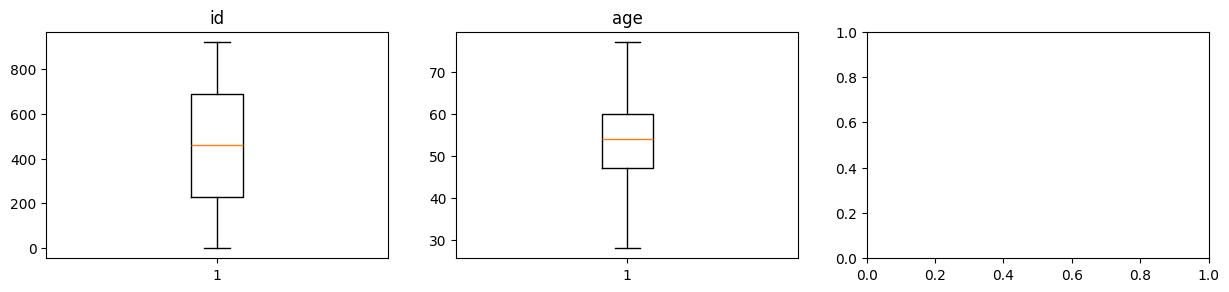

In [10]:
# 1. Descriptive Statistics and Distribution Analysis
descriptive_stats = df_heart.describe()
display(descriptive_stats)

print("\nObservations on Data Distributions:")
for col in df_heart.columns:
  print(f"- {col}:")
  # Add observations about each column's distribution (skew, tails, etc.).
  # Example:
  # if descriptive_stats[col]['mean'] < descriptive_stats[col]['50%']:
  #     print("  This column appears to be left-skewed.")


# 2. Missing Value Check
missing_values = df_heart.isnull().sum()
print("\nMissing Values per column:")
print(missing_values)

# Propose a strategy for handling missing values (if any).
# Example:
# if missing_values.any():
#   print("\nMissing value handling strategy: Imputation with the mean for numeric features.")


# 3. Outlier Detection (Box Plots and Z-scores)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 10))  # Adjust figure size for better readability
for i, col in enumerate(df_heart.columns):
    plt.subplot(3, 3, i + 1)
    plt.boxplot(df_heart[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Calculate z-scores
z = np.abs((df_heart - df_heart.mean()) / df_heart.std())

# Define a threshold for outlier detection (e.g., z-score > 3)
threshold = 3
outliers = z > threshold

print("\nPotential Outliers (based on z-score > 3):")
display(outliers.sum())

# Propose a strategy for handling outliers (e.g., winsorizing, removal, transformation)
# Example:
# print("\nOutlier handling strategy: Winsorizing values beyond z-score of 3")